In [1]:
import pandas as pd
import numpy as np

In [2]:
#keep the variables that I need right now
merge=pd.read_csv('../data/interim/merged_data.csv')
merge=merge.rename(columns={'ENGLAND_WALES_DEMAND':'demand'})
merge['time']=pd.to_datetime(merge['time'])
print(merge.columns)

Index(['time', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
       'ND', 'TSD', 'demand', 'EMBEDDED_WIND_GENERATION',
       'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION',
       'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING',
       'SCOTTISH_TRANSFER', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW',
       'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW',
       'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW'],
      dtype='str')


In [3]:
keep_cols=[
    "time",
    "demand",
    "temperature_2m"
]
df=merge[keep_cols].copy()
print(df.isna().sum())
print(df.duplicated().sum())

time              0
demand            0
temperature_2m    0
dtype: int64
0


In [4]:
#calender feature
df['hour']=df['time'].dt.hour
df['hour_sin']=np.sin(2*np.pi*df['hour']/24)
df['hour_cos']=np.cos(2*np.pi*df['hour']/24)
df['month']=df['time'].dt.month
df['dayofweek']=df['time'].dt.dayofweek

In [5]:
#lag
df['demand_lag_1']=df['demand'].shift(1)
df['demand_lag_24']=df['demand'].shift(24)
df['demand_lag_168']=df['demand'].shift(168)

In [6]:
#roll
df['demand_roll_24']=df['demand'].shift(1).rolling(24).mean()
df['demand_roll_24std']=df['demand'].shift(1).rolling(24).std()
df['temp_roll_24']=df['temperature_2m'].shift(1).rolling(24).mean()


In [7]:
print(df.columns)
print(df.shape)
print(df.head())
df=df.dropna().copy()
print(df.isna().sum())


Index(['time', 'demand', 'temperature_2m', 'hour', 'hour_sin', 'hour_cos',
       'month', 'dayofweek', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168',
       'demand_roll_24', 'demand_roll_24std', 'temp_roll_24'],
      dtype='str')
(87672, 14)
                 time   demand  temperature_2m  hour  hour_sin  hour_cos  \
0 2016-01-01 00:00:00  20042.5             4.8     0  0.000000  1.000000   
1 2016-01-01 01:00:00  19894.0             4.1     1  0.258819  0.965926   
2 2016-01-01 02:00:00  18451.0             3.4     2  0.500000  0.866025   
3 2016-01-01 03:00:00  17611.0             2.5     3  0.707107  0.707107   
4 2016-01-01 04:00:00  16631.5             1.5     4  0.866025  0.500000   

   month  dayofweek  demand_lag_1  demand_lag_24  demand_lag_168  \
0      1          4           NaN            NaN             NaN   
1      1          4       20042.5            NaN             NaN   
2      1          4       19894.0            NaN             NaN   
3      1          4   

In [8]:
from src.features.ttsplit_time_sequence import tt_split_time

In [9]:
#split train test set by time sequence
x_list=df.columns.tolist()
x_list.remove('demand')
x_list.remove('time')

In [10]:
x_train,x_test,y_train,y_test=tt_split_time('demand',x_list,df,0.8)

In [11]:
from src.models.evaluate_model import evaluating_model

In [12]:
#naive baseline
y_pred_baseline=x_test['demand_lag_24']
mse_1,mae_1,rmse_1,mape_1=evaluating_model(y_test,y_pred_baseline)

MSE:  7670670.870007428
MAE:  1907.9130906805326
RMSE:  2769.5976007368704
MAPE: 6.889155584122662%


In [13]:
from src.models.standard_scaler import standardize
from sklearn.linear_model import LinearRegression

In [14]:
df['temp_sq']=df['temperature_2m']**2
print(df.head())
print(df.columns)
x_list_linear=df.columns.tolist()
x_list_linear.remove('demand')
x_list_linear.remove('time')
print(x_list_linear)

                   time   demand  temperature_2m  hour  hour_sin  hour_cos  \
168 2016-01-08 00:00:00  26616.5             3.4     0  0.000000  1.000000   
169 2016-01-08 01:00:00  26358.5             2.9     1  0.258819  0.965926   
170 2016-01-08 02:00:00  25546.5             2.5     2  0.500000  0.866025   
171 2016-01-08 03:00:00  24966.5             2.3     3  0.707107  0.707107   
172 2016-01-08 04:00:00  24461.0             2.1     4  0.866025  0.500000   

     month  dayofweek  demand_lag_1  demand_lag_24  demand_lag_168  \
168      1          4       26962.5        24151.5         20042.5   
169      1          4       26616.5        24025.5         19894.0   
170      1          4       26358.5        23480.0         18451.0   
171      1          4       25546.5        23325.5         17611.0   
172      1          4       24966.5        23392.0         16631.5   

     demand_roll_24  demand_roll_24std  temp_roll_24  temp_sq  
168    32398.416667        6071.217677      6.

In [15]:
x_train_linear,x_test_linear,y_train,y_test=tt_split_time('demand',x_list_linear,df,0.8)

In [16]:
#standard scaler
x_train_scaled,x_test_scaled=standardize(x_train_linear,x_test_linear)
#linear regression
lr_model=LinearRegression()
lr_fit=lr_model.fit(x_train_scaled,y_train)
lr_pred=lr_fit.predict(x_test_scaled)
print(lr_fit.coef_)
mse_2,mae_2,rmse_2,mape_2=evaluating_model(lr_pred,y_test)

[-116.38643278 -505.73748306  110.89478813 -381.59244781   20.64593069
   14.44970915 4202.43949205 1013.84604752 1004.75133992  -92.00450632
  -58.0220037    25.14244916  156.86689718]
MSE:  1611960.2776048852
MAE:  930.9296314102401
RMSE:  1269.6299766486632
MAPE: 3.347888139801874%


In [17]:
from src.models.linear_ridge_time_sequence import ridge_time_sequence

In [18]:
#ridge
best_model,best_alpha,cv_mse=ridge_time_sequence(x_train_linear,y_train)
ridge_pred=best_model.predict(x_test_linear)
print(best_model.named_steps['ridge'].coef_)
mse_3,mae_3,rmse_3,mape_3=evaluating_model(ridge_pred,y_test)

best alpha: 20.6913808111479
best cv mse: 1260322.6054093284
[-115.85703599 -503.76908142  109.4742604  -382.43824205   20.67353971
   14.49542008 4193.4152688  1014.98844891 1007.68460276  -88.03460977
  -58.31635091   26.0336855   155.3751268 ]
MSE:  1611333.908452997
MAE:  930.7584072526623
RMSE:  1269.3832787826525
MAPE: 3.3471950873297254%


No need to use ridge regularization, the ols consequence already stable enough that is not influenced by collinearity

In [19]:
from src.models.randomforest import RF
import matplotlib.pyplot as plt

In [20]:
x_list_rf=df.columns.tolist()
x_list_rf.remove('time')
x_list_rf.remove('demand')
x_list_rf.remove('temp_sq')
print(x_list_rf)

x_train_rf,x_test_rf,y_train,y_test=tt_split_time('demand',x_list_rf,df,0.8)

['temperature_2m', 'hour', 'hour_sin', 'hour_cos', 'month', 'dayofweek', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'demand_roll_24', 'demand_roll_24std', 'temp_roll_24']


In [21]:
#Random forest
rf_model=RF(x_train_rf,y_train,params={'n_estimators':800})
rf_pred=rf_model.predict(x_test_rf)
mse_4,mae_4,rmse_4,mape_4=evaluating_model(rf_pred,y_test)

MSE:  408235.16036246525
MAE:  436.04489397034456
RMSE:  638.9328293040398
MAPE: 1.5519755004164137%


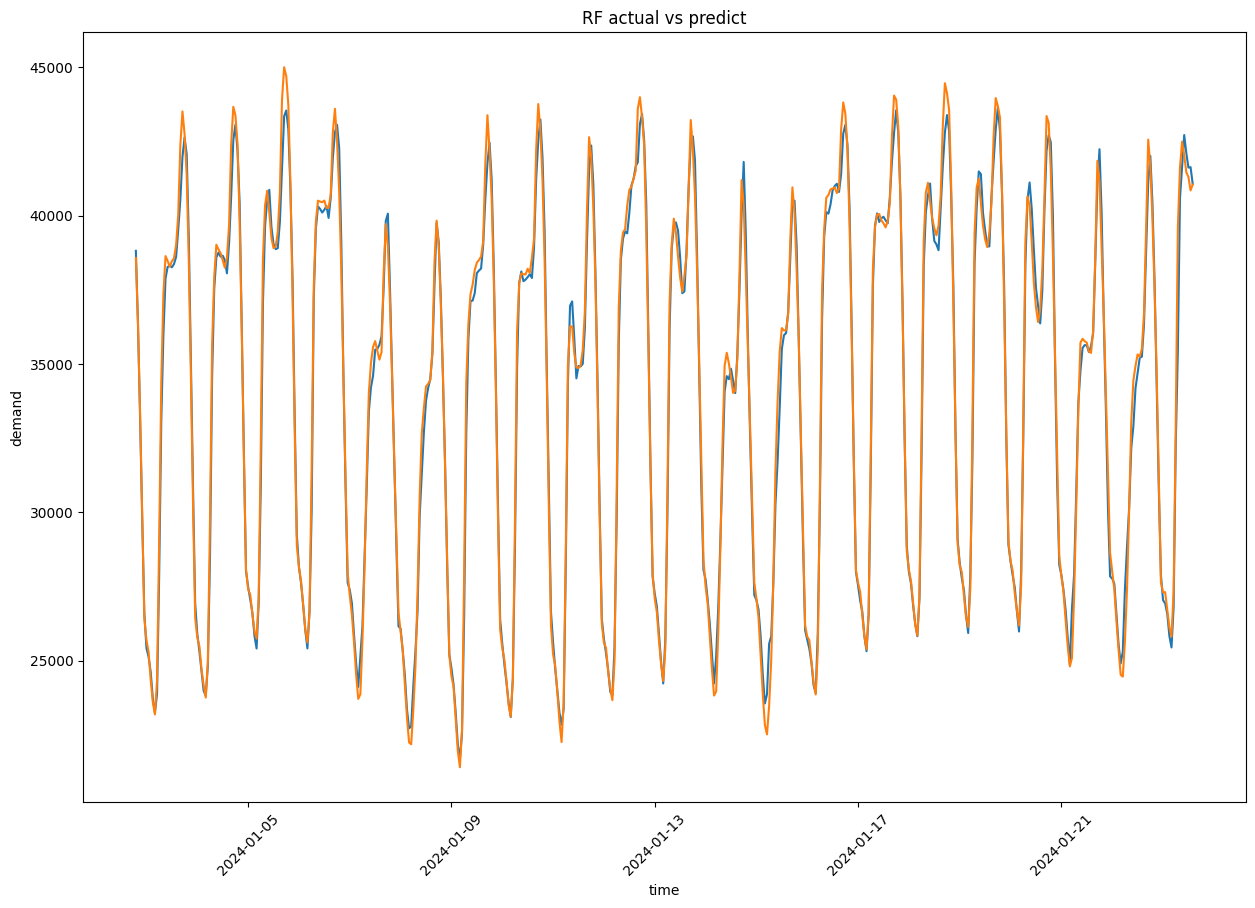

In [22]:
#actual vs predict
split_idx=int(len(df.index)*0.8)
time=df['time'][split_idx:]
plt.figure(figsize=(15,10))
plt.plot(time[:500],rf_pred[:500],label='predict')
plt.plot(time[:500],y_test[:500],label='actual')
plt.title('RF actual vs predict')
plt.xticks(rotation=45)
plt.ylabel('demand')
plt.xlabel('time')
plt.show()

Apparently the prediction don't act good on the peak.

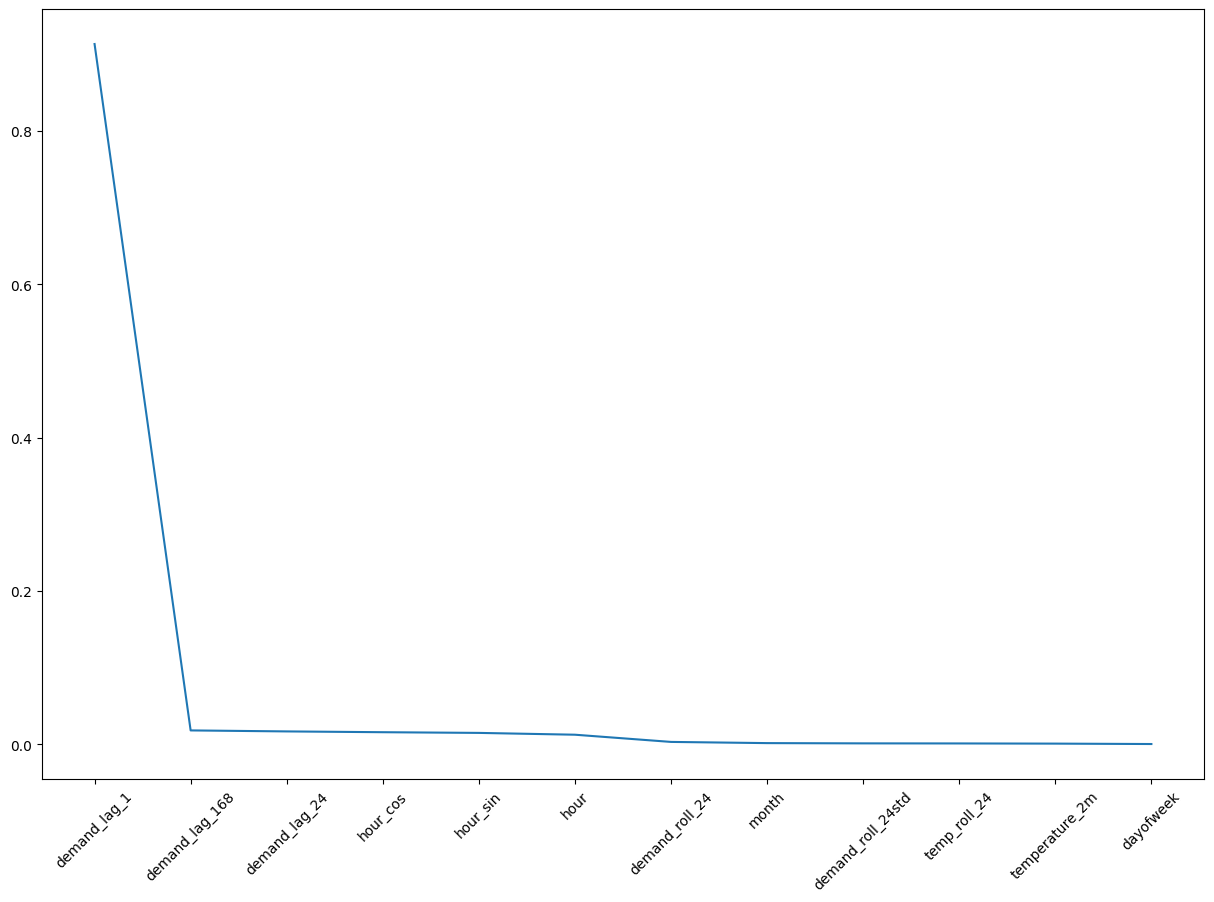

In [23]:
importance_df=pd.DataFrame({
    'feature':x_train.columns,
    'importance':rf_model.feature_importances_
}).sort_values('importance',ascending=False)

plt.figure(figsize=(15,10))
plt.plot(importance_df['feature'],importance_df['importance'],label='importance')
plt.xticks(rotation=45)
plt.show()

In [24]:
#try to improve peak values prediction
df['hour_change_1']=df['hour'].diff(1)
df=df.dropna().copy()
print(df.isna().sum())
print(df.shape)

print(x_list_rf)
x_list_rf1=x_list_rf+['hour_change_1']
x_train_rf1,x_test_rf1,y_train,y_test=tt_split_time('demand',x_list_rf1,df,0.8)

time                 0
demand               0
temperature_2m       0
hour                 0
hour_sin             0
hour_cos             0
month                0
dayofweek            0
demand_lag_1         0
demand_lag_24        0
demand_lag_168       0
demand_roll_24       0
demand_roll_24std    0
temp_roll_24         0
temp_sq              0
hour_change_1        0
dtype: int64
(87503, 16)
['temperature_2m', 'hour', 'hour_sin', 'hour_cos', 'month', 'dayofweek', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'demand_roll_24', 'demand_roll_24std', 'temp_roll_24']


In [25]:
rf_model=RF(x_train_rf1,y_train,params={'n_estimators':800})
rf_pred=rf_model.predict(x_test_rf1)
mse_5,mae_5,rmse_5,mape_5=evaluating_model(rf_pred,y_test)

MSE:  406343.7243634589
MAE:  435.7450256413919
RMSE:  637.4509583987297
MAPE: 1.5510425298671426%


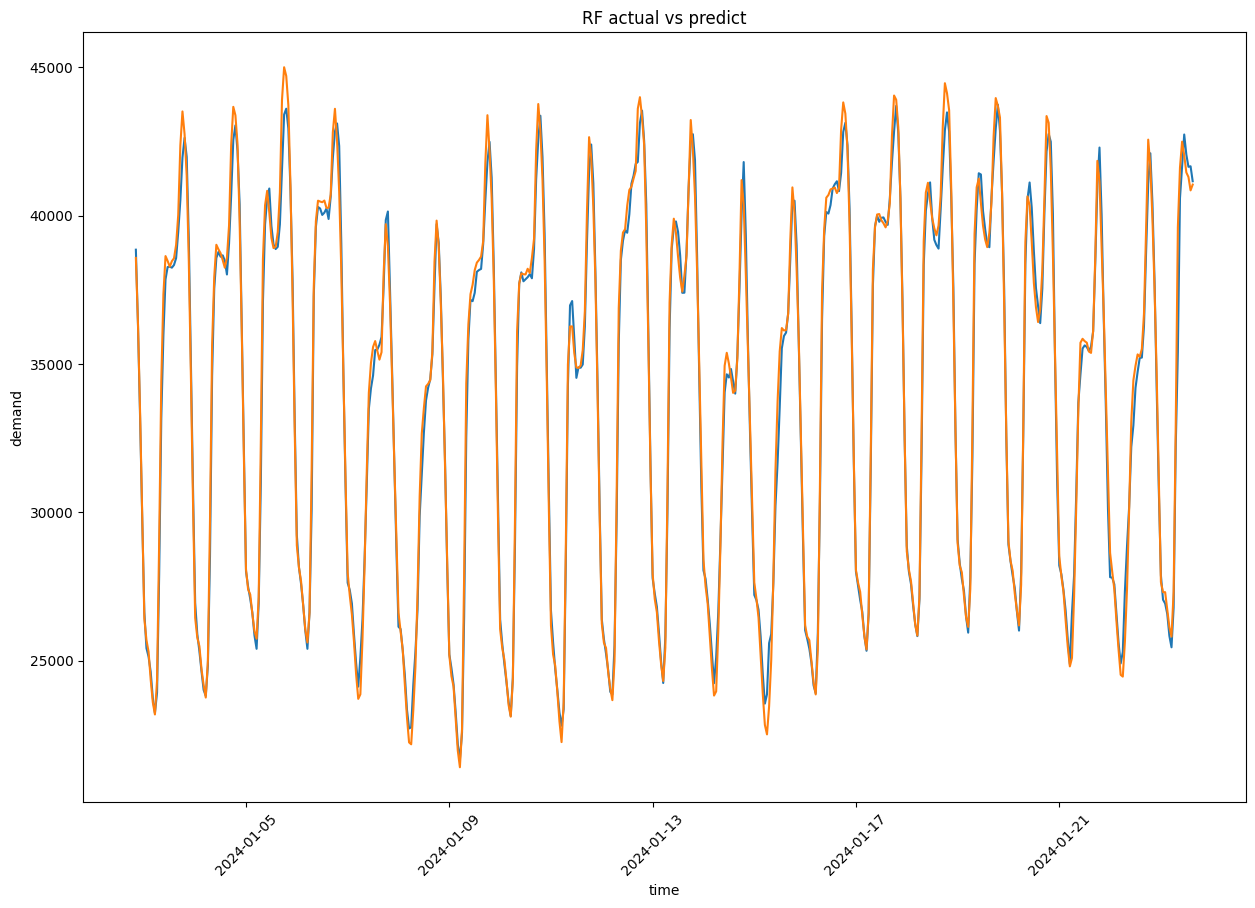

In [26]:
#actual vs predict
time=df['time'][split_idx:]
plt.figure(figsize=(15,10))
plt.plot(time[:500],rf_pred[:500],label='predict')
plt.plot(time[:500],y_test[:500],label='actual')
plt.title('RF actual vs predict')
plt.xticks(rotation=45)
plt.ylabel('demand')
plt.xlabel('time')
plt.show()

try to improve by adding more variable, turn out the result didn't change too much

In [27]:
#try another way to improve
df['peak_hour']=df['hour'].isin([7,8,9,17,18,19]).astype(int)

print(x_list_rf)
x_list_rf2=x_list_rf+['peak_hour']
print(x_list_rf2)

['temperature_2m', 'hour', 'hour_sin', 'hour_cos', 'month', 'dayofweek', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'demand_roll_24', 'demand_roll_24std', 'temp_roll_24']
['temperature_2m', 'hour', 'hour_sin', 'hour_cos', 'month', 'dayofweek', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'demand_roll_24', 'demand_roll_24std', 'temp_roll_24', 'peak_hour']


In [28]:
x_train_rf2,x_test_rf2,y_train,y_test=tt_split_time('demand',x_list_rf2,df,0.8)

In [29]:
rf_model=RF(x_train_rf2,y_train,params={'n_estimators':800})
rf_pred=rf_model.predict(x_test_rf2)
mse_6,mae_6,rmse_6,mape_6=evaluating_model(rf_pred,y_test)

MSE:  403856.5052569837
MAE:  434.24318160390834
RMSE:  635.4970536965405
MAPE: 1.546551079328606%


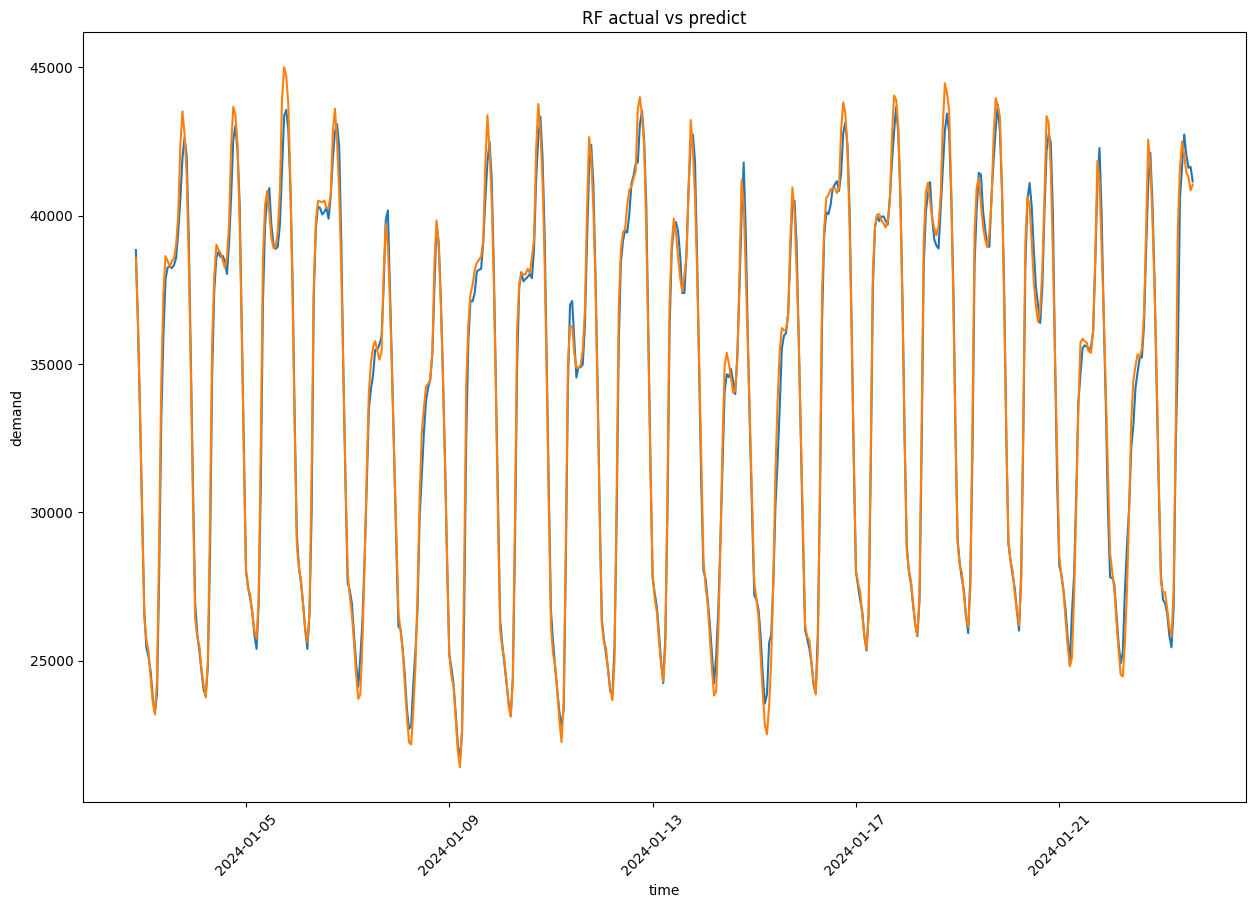

In [30]:
#actual vs predict
time=df['time'][split_idx:]
plt.figure(figsize=(15,10))
plt.plot(time[:500],rf_pred[:500],label='predict')
plt.plot(time[:500],y_test[:500],label='actual')
plt.title('RF actual vs predict')
plt.xticks(rotation=45)
plt.ylabel('demand')
plt.xlabel('time')
plt.show()

could not apparently improve,keep the third consequence of RF model and continue to do the next step.

In [31]:
print(x_list_rf2)
x_list=df.columns.tolist()
print([x for x in x_list if x not in x_list_rf2])

['temperature_2m', 'hour', 'hour_sin', 'hour_cos', 'month', 'dayofweek', 'demand_lag_1', 'demand_lag_24', 'demand_lag_168', 'demand_roll_24', 'demand_roll_24std', 'temp_roll_24', 'peak_hour']
['time', 'demand', 'temp_sq', 'hour_change_1']


In [32]:
from src.extract.save_dir import saved_data_dir

In [33]:
df=df.drop(columns=['temp_sq','hour_change_1'])
print(df.head())
saved_data_dir('merged_data_demand_model.csv',df,'../data/interim/')

                   time   demand  temperature_2m  hour  hour_sin  hour_cos  \
169 2016-01-08 01:00:00  26358.5             2.9     1  0.258819  0.965926   
170 2016-01-08 02:00:00  25546.5             2.5     2  0.500000  0.866025   
171 2016-01-08 03:00:00  24966.5             2.3     3  0.707107  0.707107   
172 2016-01-08 04:00:00  24461.0             2.1     4  0.866025  0.500000   
173 2016-01-08 05:00:00  25413.5             1.8     5  0.965926  0.258819   

     month  dayofweek  demand_lag_1  demand_lag_24  demand_lag_168  \
169      1          4       26616.5        24025.5         19894.0   
170      1          4       26358.5        23480.0         18451.0   
171      1          4       25546.5        23325.5         17611.0   
172      1          4       24966.5        23392.0         16631.5   
173      1          4       24461.0        24477.0         16393.5   

     demand_roll_24  demand_roll_24std  temp_roll_24  peak_hour  
169    32501.125000        5945.178842      

In [34]:
df['demand_prediction']=rf_model.predict(df[x_list_rf2])
df['error']=df['demand']-df['demand_prediction']
df['error_abs']=(df['demand']-df['demand_prediction']).abs()
print(df.shape)
print(df.head())

(87503, 18)
                   time   demand  temperature_2m  hour  hour_sin  hour_cos  \
169 2016-01-08 01:00:00  26358.5             2.9     1  0.258819  0.965926   
170 2016-01-08 02:00:00  25546.5             2.5     2  0.500000  0.866025   
171 2016-01-08 03:00:00  24966.5             2.3     3  0.707107  0.707107   
172 2016-01-08 04:00:00  24461.0             2.1     4  0.866025  0.500000   
173 2016-01-08 05:00:00  25413.5             1.8     5  0.965926  0.258819   

     month  dayofweek  demand_lag_1  demand_lag_24  demand_lag_168  \
169      1          4       26616.5        24025.5         19894.0   
170      1          4       26358.5        23480.0         18451.0   
171      1          4       25546.5        23325.5         17611.0   
172      1          4       24966.5        23392.0         16631.5   
173      1          4       24461.0        24477.0         16393.5   

     demand_roll_24  demand_roll_24std  temp_roll_24  peak_hour  \
169    32501.125000        5945

In [35]:
saved_data_dir('merge_data_demand_output.csv',df,'../data/interim/')

merge_data_demand_output.csv saved to C:\Users\24363\Desktop\powering_market_forecasting_analytics\data\interim\merge_data_demand_output.csv
